In [1]:
import tomllib
import numpy as np
import matplotlib.pyplot as plt

import AEIC.trajectories.builders as tb
from AEIC.config import Config, config
from AEIC.missions import Mission
from AEIC.performance.models import PerformanceModel

# Introduction

This notebook is a comparison of different mass iteration schemes used by the base trajectory builder. The existing mass iteration examines the difference between the fuel loaded at the beginning of the mission to the actual amount burned while flying. Convergence is determined by a relative tolerance (default `1e-6`) measured against the fraction of excess fuel:

$$
\delta = \frac{\text{Actual Fuel Burned} - \text{Fuel Loaded}}{\text{Fuel Loaded}}
$$

There are currently three methods implemented to update the fuel and total mass from iteration to iteration. These are as follows:

- **Naive** - If the mission ends with $dM$ more fuel burned than we initially loaded, adjust the starting mass and fuel mass by $+dM$ and try flying the mission again.
- **Range-Corrected** - Using the range equation, account for the additional fuel required to carry the $+dM$ extra while meeting the same range.
- **Averaged** - A simple arithmetic average of Naive and Range-Corrected approaches. This is due to the Range-Corrected method tending to overestimate the amount of fuel to be added/subtracted, leading to increased iterations vs. the naive approach.

The below notebook demonstrates all three in an iteration count vs. specified tolerance basis for each of the to sample missions in `data/missions/sample_missions_10.toml`.

In [2]:
Config.load();

Use the sample performance model.

In [3]:
performance_model = PerformanceModel.load(
    config.file_location('performance/sample_performance_model.toml')
)

In [4]:
missions_file = config.file_location('missions/sample_missions_10.toml')
with open(missions_file, 'rb') as f:
    mission_dict = tomllib.load(f)
sample_missions = Mission.from_toml(mission_dict)

# Testing Different Iteration Methods

We make a builder for each iteration correction scheme and run them through a tolerance sweep for each mission. The results are plotted below. In all cases, the averaging approach performed best.

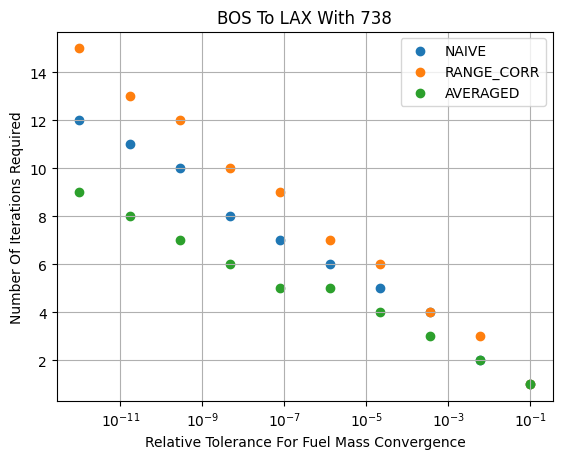

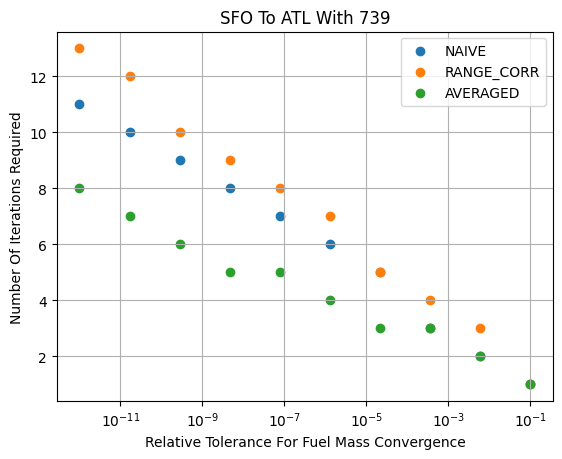

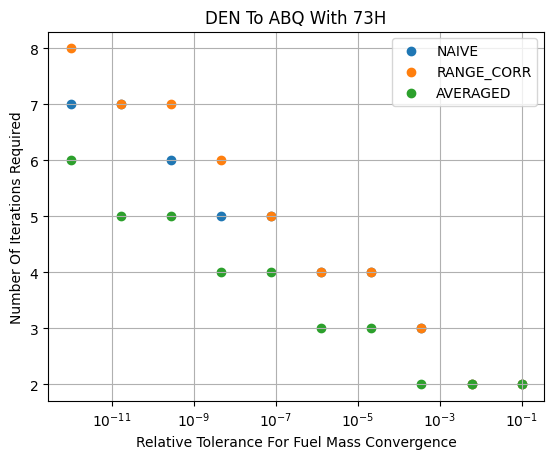

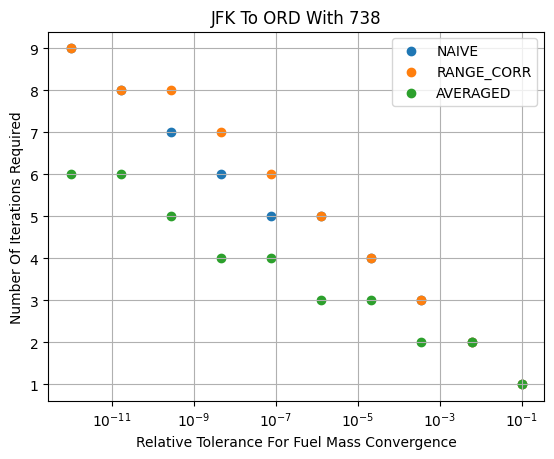

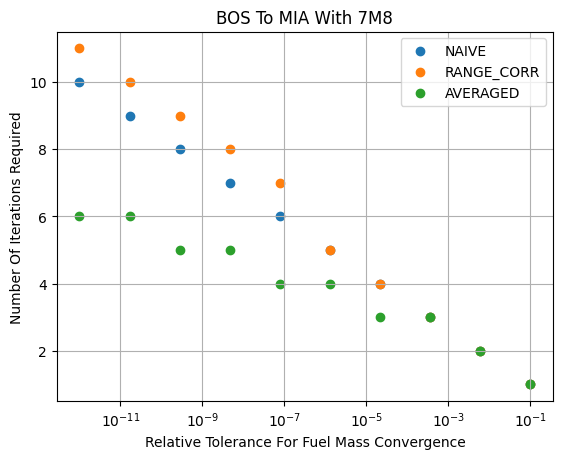

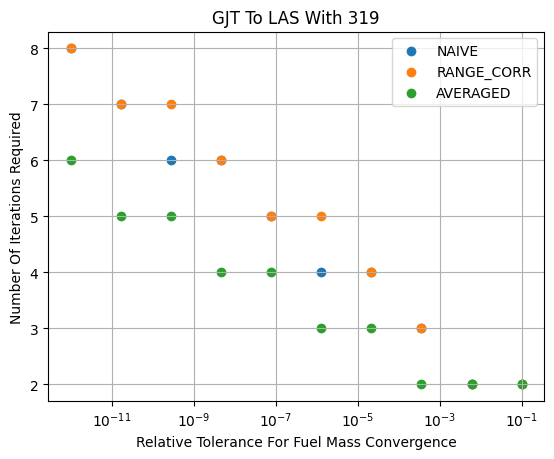

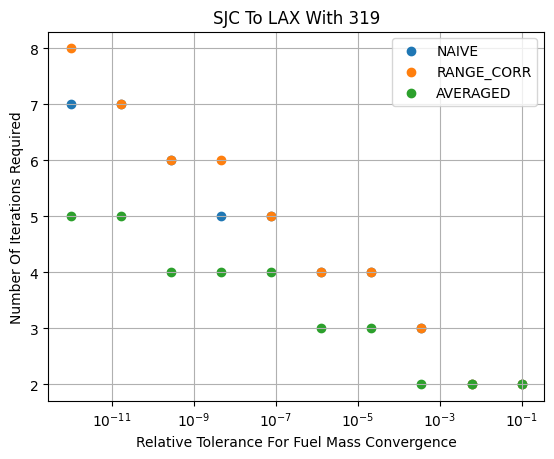

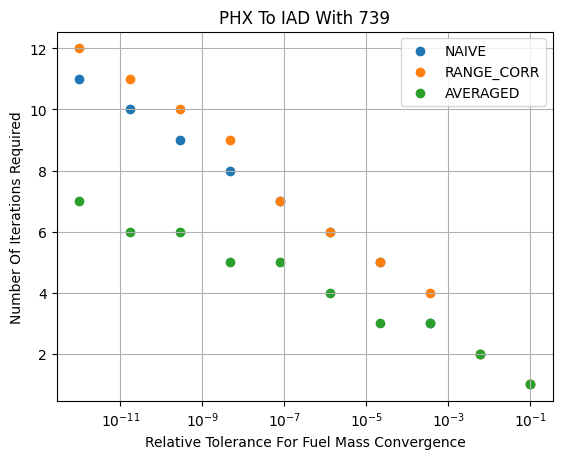

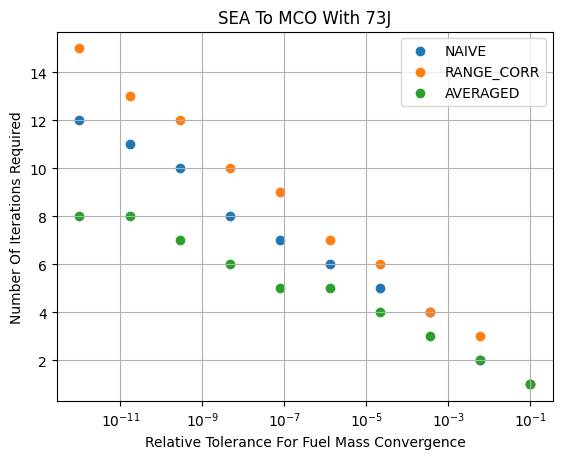

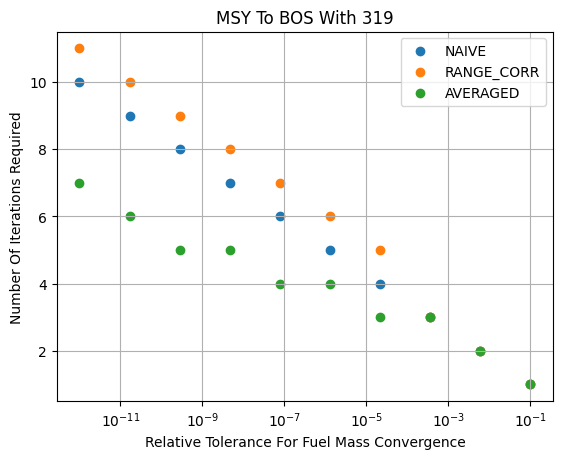

In [5]:
def run_builder_comp(ax, builders:list[tb.LegacyBuilder], mis, perf, min_tol, max_tol, n_tols):
    tols = np.logspace(min_tol, max_tol, n_tols)
    
    for bld in builders:
        data = []
        for tol in tols:
            bld.options.mass_iter_reltol = tol
            _ = bld.fly(perf, mis)
            data.append(bld.iters)
        ax.scatter(tols, data, label=bld.options.iter_method.name)

    return ax


bld_naive = tb.LegacyBuilder(options=tb.Options(
    iterate_mass=True, 
    iter_method=tb.MassIterMethod.NAIVE, 
    max_mass_iters=50,
))

bld_rng = tb.LegacyBuilder(options=tb.Options(
    iterate_mass=True, 
    iter_method=tb.MassIterMethod.RANGE_CORR, 
    max_mass_iters=50,
))

bld_avg = tb.LegacyBuilder(options=tb.Options(
    iterate_mass=True, 
    iter_method=tb.MassIterMethod.AVERAGED, 
    max_mass_iters=50,
))

for mis in sample_missions:
    fig, ax = plt.subplots()
    ax.set_xscale('log')

    ax = run_builder_comp(ax, [bld_naive, bld_rng, bld_avg], mis=mis, perf=performance_model, min_tol=-12, max_tol=-1, n_tols=10)

    ax.legend()
    ax.grid(visible=True, which='both')
    ax.set_title(f'{mis.origin} To {mis.destination} With {mis.aircraft_type}')
    ax.set_xlabel('Relative Tolerance For Fuel Mass Convergence')
    ax.set_ylabel('Number Of Iterations Required')